In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [2]:
df = pd.read_csv('Omron_AllReviews.csv')

In [3]:
# Remove rows where 'body' is NaN or an empty string
df = df.dropna(subset=['body'])  # Remove rows with NaN in 'body'
df = df[df['body'].str.strip() != '']  # Remove rows with empty or whitespace-only strings

# VADER model

In [4]:
from nltk.sentiment import SentimentIntensityAnalyzer
from tqdm.notebook import tqdm   # tqdm is for progress bar

In [5]:
# create preprocess_text function
def preprocess_text(text):

    # Tokenize the text

    tokens = nltk.word_tokenize(text.lower())




    # Remove stop words

    filtered_tokens = [token for token in tokens if token not in stopwords.words('english')]




    # Lemmatize the tokens

    lemmatizer = WordNetLemmatizer()

    lemmatized_tokens = [lemmatizer.lemmatize(token) for token in filtered_tokens]




    # Join the tokens back into a string

    processed_text = ' '.join(lemmatized_tokens)

    return processed_text

# apply the function df


df['body'] = df['body'].apply(preprocess_text)
df

,product,title,rating,body,Model number
0,Omron HEM 7143T1 Digital Bluetooth Blood Press...,5.0 out of 5 stars\nAccurate bp monitor,5,'s accurate reliable affordable . great product .,7143T1
1,Omron HEM 7143T1 Digital Bluetooth Blood Press...,"4.0 out of 5 stars\nGood, but....",4,omron gold standard home bp measurement . good...,7143T1
2,Omron HEM 7143T1 Digital Bluetooth Blood Press...,5.0 out of 5 stars\nPrecision and Convenience ...,5,"recently purchased blood pressure meter mom , ...",7143T1
3,Omron HEM 7143T1 Digital Bluetooth Blood Press...,5.0 out of 5 stars\nFullfilled my wish,5,searched found product amazon . good value mon...,7143T1
4,Omron HEM 7143T1 Digital Bluetooth Blood Press...,3.0 out of 5 stars\nLots of features are missing.,3,"doubt quality , size cup short , accuracy good...",7143T1
...,...,...,...,...,...
846,Omron Smart Elite+ HEM 7600T Tubeless 360° Acc...,5.0 out of 5 stars\nExcellent,5,excellent hassle free,7600T
847,Omron Smart Elite+ HEM 7600T Tubeless 360° Acc...,5.0 out of 5 stars\nVery good quality Blood pr...,5,"bought omron smart elite+ hem 7600t may 2019 ,...",7600T
848,Omron Smart Elite+ HEM 7600T Tubeless 360° Acc...,4.0 out of 5 stars\nEasy to use ...as per qual...,4,per rate litt ... bit costly,7600T
849,Omron Smart Elite+ HEM 7600T Tubeless 360° Acc...,5.0 out of 5 stars\nEasy to use,5,good looking,7600T


In [6]:
sia = SentimentIntensityAnalyzer()

In [7]:
# Running polarity score on entire dataset

res_p = {}
for i,row in tqdm(df.iterrows(), total=len(df)):
    text = row['body']
    myid = i
    res_p[myid] = sia.polarity_scores(text)


  0%|          | 0/848 [00:00<?, ?it/s]

In [8]:
vaders_p = pd.DataFrame(res_p).T
vaders_p.head()

,neg,neu,pos,compound
0,0.000,0.549,0.451,0.6249
1,0.000,0.700,0.300,0.9563
2,0.082,0.650,0.268,0.9590
3,0.000,0.533,0.467,0.7184
4,0.082,0.621,0.297,0.7650


In [9]:
# merging df with vaders so that reviews and their corresponding scores are together

vaders_p = pd.concat([df, vaders_p], axis=1)
vaders_p.head()

,product,title,rating,body,Model number,neg,neu,pos,compound
0,Omron HEM 7143T1 Digital Bluetooth Blood Press...,5.0 out of 5 stars\nAccurate bp monitor,5,'s accurate reliable affordable . great product .,7143T1,0.000,0.549,0.451,0.6249
1,Omron HEM 7143T1 Digital Bluetooth Blood Press...,"4.0 out of 5 stars\nGood, but....",4,omron gold standard home bp measurement . good...,7143T1,0.000,0.700,0.300,0.9563
2,Omron HEM 7143T1 Digital Bluetooth Blood Press...,5.0 out of 5 stars\nPrecision and Convenience ...,5,"recently purchased blood pressure meter mom , ...",7143T1,0.082,0.650,0.268,0.9590
3,Omron HEM 7143T1 Digital Bluetooth Blood Press...,5.0 out of 5 stars\nFullfilled my wish,5,searched found product amazon . good value mon...,7143T1,0.000,0.533,0.467,0.7184
4,Omron HEM 7143T1 Digital Bluetooth Blood Press...,3.0 out of 5 stars\nLots of features are missing.,3,"doubt quality , size cup short , accuracy good...",7143T1,0.082,0.621,0.297,0.7650


In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Convert ratings to actual sentiment labels
def get_actual_sentiment(rating):
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"

# Convert compound score to predicted sentiment labels
def get_predicted_sentiment(compound):
    if compound >= 0.05:
        return "Positive"
    elif -0.05 < compound < 0.05:
        return "Neutral"
    else:
        return "Negative"

# Apply the functions to create actual and predicted sentiment columns
vaders_p['actual_sentiment'] = vaders_p['rating'].apply(get_actual_sentiment)
vaders_p['predicted_sentiment'] = vaders_p['compound'].apply(get_predicted_sentiment)

# Calculate metrics
accuracy_p = accuracy_score(vaders_p['actual_sentiment'], vaders_p['predicted_sentiment'])
precision_p = precision_score(vaders_p['actual_sentiment'], vaders_p['predicted_sentiment'], average='weighted')
recall_p = recall_score(vaders_p['actual_sentiment'], vaders_p['predicted_sentiment'], average='weighted')
f1_p = f1_score(vaders_p['actual_sentiment'], vaders_p['predicted_sentiment'], average='weighted')

print(f"Accuracy_p: {accuracy_p}")
print(f"Precision_p: {precision_p}")
print(f"Recall_p: {recall_p}")
print(f"F1 Score_p: {f1_p}")


Accuracy_p: 0.7783018867924528
Precision_p: 0.8148402403414196
Recall_p: 0.7783018867924528
F1 Score_p: 0.7950826632211635


# ROBERTA model

In [11]:
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification
from scipy.special import softmax

In [12]:
MODEL = f"cardiffnlp/twitter-roberta-base-sentiment"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)

#loading a model on twitter dataset
#using trained weights of the above model and applying to our dataset.

In [13]:
example = df['body'][88]

In [14]:
#Run for ROBERTA model

encoded_text = tokenizer(example, return_tensors='pt')
output = model(**encoded_text) #running pretrained model
scores = output[0][0].detach().numpy() #convert tensor to numpy to store locally
scores = softmax(scores) ##what is softmax?????

In [15]:
scores_dict = {
    'roberta_neg' : scores[0],
    'roberta_neu' : scores[1],
    'roberta_pos' : scores[2]
}
print(scores_dict)

{'roberta_neg': 0.022788323, 'roberta_neu': 0.23489048, 'roberta_pos': 0.7423212}


In [16]:
#running Roberta on the whole dataset

def polarity_scores_roberta(example):
    encoded_text = tokenizer(example, return_tensors='pt')
    output = model(**encoded_text)
    scores = output[0][0].detach().numpy()
    scores = softmax(scores)
    scores_dict = {
        'roberta_neg' : scores[0],
        'roberta_neu' : scores[1],
        'roberta_pos' : scores[2]
    }
    return scores_dict

In [17]:
#combining vader and roberta results

res = {}
for i, row in tqdm(df.iterrows(), total=len(df)):
    try:
        text = row['body']
        myid = i
        vader_result = sia.polarity_scores(text)
        vader_result_rename = {}
        for key, value in vader_result.items():
            vader_result_rename[f"vader_{key}"] = value
        roberta_result = polarity_scores_roberta(text)
        both = {**vader_result_rename, **roberta_result}
        res[myid] = both
    except RuntimeError:
        print(f'Broke for id {myid}')

  0%|          | 0/848 [00:00<?, ?it/s]

Broke for id 516


In [18]:
# Convert the `res` dictionary to a DataFrame
res_df = pd.DataFrame.from_dict(res, orient='index')

# Merge the sentiment DataFrame with the original DataFrame on the index
results_df = df.merge(res_df, left_index=True, right_index=True)

# Display the merged DataFrame
results_df.head()

,product,title,rating,body,Model number,vader_neg,vader_neu,vader_pos,vader_compound,roberta_neg,roberta_neu,roberta_pos
0,Omron HEM 7143T1 Digital Bluetooth Blood Press...,5.0 out of 5 stars\nAccurate bp monitor,5,'s accurate reliable affordable . great product .,7143T1,0.000,0.549,0.451,0.6249,0.003879,0.052501,0.943620
1,Omron HEM 7143T1 Digital Bluetooth Blood Press...,"4.0 out of 5 stars\nGood, but....",4,omron gold standard home bp measurement . good...,7143T1,0.000,0.700,0.300,0.9563,0.077609,0.449358,0.473033
2,Omron HEM 7143T1 Digital Bluetooth Blood Press...,5.0 out of 5 stars\nPrecision and Convenience ...,5,"recently purchased blood pressure meter mom , ...",7143T1,0.082,0.650,0.268,0.9590,0.005300,0.141869,0.852831
3,Omron HEM 7143T1 Digital Bluetooth Blood Press...,5.0 out of 5 stars\nFullfilled my wish,5,searched found product amazon . good value mon...,7143T1,0.000,0.533,0.467,0.7184,0.007357,0.132317,0.860326
4,Omron HEM 7143T1 Digital Bluetooth Blood Press...,3.0 out of 5 stars\nLots of features are missing.,3,"doubt quality , size cup short , accuracy good...",7143T1,0.082,0.621,0.297,0.7650,0.020929,0.196634,0.782437


In [19]:
#Use lambda function to label tweet as positive, negative or neutral
results_df['Roberta_Analysis'] = results_df.apply(lambda x:'Negative' if x['roberta_neg'] >
                     x['roberta_neu'] and x['roberta_neu']
                     > x['roberta_pos'] else ('Neutral' if x['roberta_neu']>x['roberta_pos'] else 'Positive'),axis=1)
results_df['Roberta_Analysis'].head()

0    Positive
1    Positive
2    Positive
3    Positive
4    Positive
Name: Roberta_Analysis, dtype: object

In [20]:
# Convert ratings to actual sentiment labels
def get_actual_sentiment(rating):
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"

# Convert compound score to predicted sentiment labels
def get_predicted_sentiment(compound):
    if compound >= 0.05:
        return "Positive"
    elif -0.05 < compound < 0.05:
        return "Neutral"
    else:
        return "Negative"

# Apply the functions to create actual and predicted sentiment columns
results_df['Vader_Analysis'] = results_df['vader_compound'].apply(get_predicted_sentiment)
results_df['actual_sentiment'] = results_df['rating'].apply(get_actual_sentiment)


In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_score_vaders = accuracy_score(results_df['actual_sentiment'],results_df['Vader_Analysis'])
precision_score_vaders = precision_score(results_df['actual_sentiment'],results_df['Vader_Analysis'], average='weighted')
recall_score_vaders = recall_score(results_df['actual_sentiment'],results_df['Vader_Analysis'], average='weighted')
f1_score_vaders = f1_score(results_df['actual_sentiment'],results_df['Vader_Analysis'], average='weighted')

accuracy_score_roberta = accuracy_score(results_df['actual_sentiment'],results_df['Roberta_Analysis'])
precision_score_roberta = precision_score(results_df['actual_sentiment'],results_df['Roberta_Analysis'], average='weighted')
recall_score_roberta = recall_score(results_df['actual_sentiment'],results_df['Roberta_Analysis'], average='weighted')
f1_score_roberta = f1_score(results_df['actual_sentiment'],results_df['Roberta_Analysis'], average='weighted') # average='weighted' because 3 classes involved

In [22]:
print('VADER RESULTS')
print(f"Accuracy_v: {accuracy_score_vaders}")
print(f"Precision_v: {precision_score_vaders}")
print(f"Recall_v: {recall_score_vaders}")
print(f"F1 Score_v: {f1_score_vaders}")

print('ROBERTA RESULTS')
print(f"Accuracy_r: {accuracy_score_roberta}")
print(f"Precision_r: {precision_score_roberta}")
print(f"Recall_r: {recall_score_roberta}")
print(f"F1 Score_r: {f1_score_roberta}")

VADER RESULTS
Accuracy_v: 0.7792207792207793
Precision_v: 0.8154405716179469
Recall_v: 0.7792207792207793
F1 Score_v: 0.79584033202674
ROBERTA RESULTS
Accuracy_r: 0.6953955135773318
Precision_r: 0.8690244672133592
Recall_r: 0.6953955135773318
F1 Score_r: 0.7585501464567237


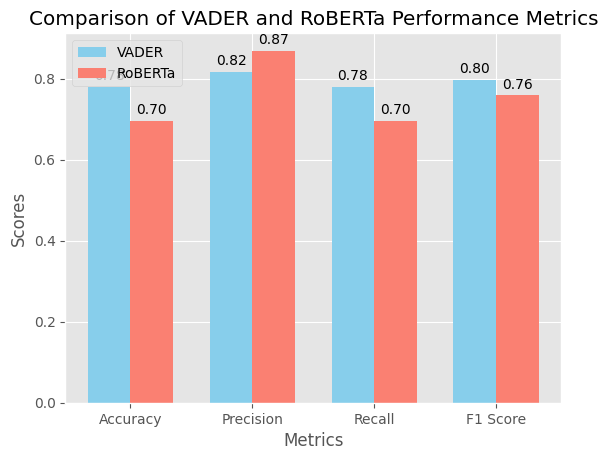

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Define the metrics and their values for VADER and RoBERTa
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
vader_results = [0.7792207792207793, 0.8154405716179469, 0.7792207792207793, 0.79584033202674]
roberta_results = [0.6953955135773318, 0.8690244672133592, 0.6953955135773318, 0.7585501464567237]

# Set up the bar chart
x = np.arange(len(metrics))  # the label locations
width = 0.35  # width of the bars

# Create the figure and axes
fig, ax = plt.subplots()

# Add bars for VADER and RoBERTa results
bars1 = ax.bar(x - width/2, vader_results, width, label='VADER', color='skyblue')
bars2 = ax.bar(x + width/2, roberta_results, width, label='RoBERTa', color='salmon')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Metrics')
ax.set_ylabel('Scores')
ax.set_title('Comparison of VADER and RoBERTa Performance Metrics')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

# Label each bar with its value
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

plt.show()